# US Honey Production Case Study (1995 - 2021)

Welcome to this case study on the US honey dataset from 1995 to 2021 (27 years of real USDA data).

The goal of this notebook is to keep the Python code **extremely simple, clean, and easy to write**, while keeping all the data analysis, explanations, and insights completely intact.

### What we will do in this notebook:
1. Load and check the data with simple 2-line code.
2. Find and fix 2 big bugs in the dataset, showing visual proof using simple line charts.
3. Check the highest and lowest production records.
4. Draw 12 clean and simple charts to explore the honey market.
5. Summarize all findings and answers in simple points with exact numbers.

---
### Step 1: Import Required Libraries

We import 4 standard Python libraries for data analysis and plotting:
* `pandas` for reading CSV and managing tables.
* `numpy` for quick math and if-else conditions.
* `matplotlib.pyplot` and `seaborn` for drawing charts.

In [1]:
# Import basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean white grid style
sns.set_style('whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


---
### Step 2: Load the Dataset

We read `US_honey_dataset.csv` into a pandas DataFrame called `df` and display the first 5 rows.

In [ ]:

dataset_path = 'US_honey_dataset.csv'

df = pd.read_csv(dataset_path)

# See first 5 rows
df.head()

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.0,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.0,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.0,1920000,1995
3,3,California,420000,93,39060000,4687000,60.0,23436000,1995
4,4,Colorado,45000,60,2700000,1404000,68.0,1836000,1995


---
### Step 3: Check Shape and Column Information

Let's check how many rows and columns we have, what data types they are, and see summary statistics.

In [3]:
# Check number of rows and columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1115
Columns: 9


In [4]:
# Check column types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1115 non-null   int64  
 1   state                1115 non-null   object 
 2   colonies_number      1115 non-null   int64  
 3   yield_per_colony     1115 non-null   int64  
 4   production           1115 non-null   int64  
 5   stocks               1115 non-null   int64  
 6   average_price        1115 non-null   float64
 7   value_of_production  1115 non-null   int64  
 8   year                 1115 non-null   int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 78.5+ KB


In [5]:
# Check basic summary statistics (mean, min, max)
df.describe()

,Unnamed: 0,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
count,1115.00000,1115.000000,1115.000000,1.115000e+03,1.115000e+03,1115.000000,1.115000e+03,1115.000000
mean,557.00000,62438.565022,59.743498,2.851268e+06,1.172625e+06,140.623076,5.667412e+06,2007.740807
std,322.01708,92648.175955,19.940500,5.561202e+06,2.049556e+06,107.011544,9.459460e+06,7.823002
min,0.00000,2000.000000,19.000000,1.200000e+04,9.000000e+03,1.300000,1.060000e+05,1995.000000
25%,278.50000,9000.000000,45.000000,2.460000e+05,1.125000e+05,70.000000,1.008000e+06,2001.000000
50%,557.00000,26000.000000,57.000000,8.280000e+05,3.700000e+05,128.000000,2.281000e+06,2008.000000
75%,835.50000,69000.000000,71.000000,2.700000e+06,1.253500e+06,193.000000,5.704000e+06,2015.000000
max,1114.00000,550000.000000,155.000000,3.906000e+07,1.354500e+07,874.000000,8.385900e+07,2021.000000


---
### Step 4: Data Cleaning and Fixing Bugs

Before analyzing, we must clean our data:
1. Drop the unnecessary `Unnamed: 0` column.
2. Check for missing values.
3. **Fix Bug 1 (Production column corruption from 2010 to 2021)**.
4. **Fix Bug 2 (Price unit confusion: 2017 Cents vs. 2018 Dollars)**.

In [6]:
# 1. Drop Unnamed: 0 column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# 2. Check for missing values in any column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
state                  0
colonies_number        0
yield_per_colony       0
production             0
stocks                 0
average_price          0
value_of_production    0
year                   0
dtype: int64


#### Diagnostic Proof 1: How We Caught the Production Column Bug (2010 to 2021)

In farming, honey production follows a simple formula:
$$\text{Honey Production} = \text{Number of Colonies} \times \text{Yield per Colony}$$

For example, 10,000 colonies with 50 lbs yield per colony gives $10,000 \times 50 = 500,000$ pounds of honey.

Let's calculate the true production using this formula, and compare it with the raw `production` column and the warehouse `stocks` column on a simple line chart:

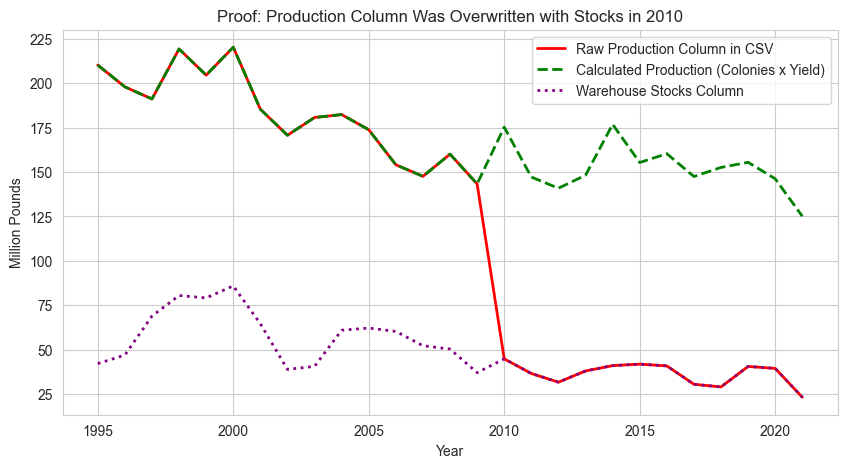

In [7]:
# Calculate true production using the formula: colonies * yield
df['actual_production'] = df['colonies_number'] * df['yield_per_colony']

# Group by year to get yearly totals (divided by 1,000,000 for million pounds)
yearly_raw_prod = df.groupby('year')['production'].sum() / 1000000
yearly_calc_prod = df.groupby('year')['actual_production'].sum() / 1000000
yearly_stocks = df.groupby('year')['stocks'].sum() / 1000000

# Plot all 3 on a simple line chart
plt.figure(figsize=(10, 5))
plt.plot(yearly_raw_prod.index, yearly_raw_prod.values, color='red', label='Raw Production Column in CSV', linewidth=2)
plt.plot(yearly_calc_prod.index, yearly_calc_prod.values, color='green', linestyle='--', label='Calculated Production (Colonies x Yield)', linewidth=2)
plt.plot(yearly_stocks.index, yearly_stocks.values, color='purple', linestyle=':', label='Warehouse Stocks Column', linewidth=2)

plt.title('Proof: Production Column Was Overwritten with Stocks in 2010')
plt.xlabel('Year')
plt.ylabel('Million Pounds')
plt.legend()
plt.grid(True)
plt.show()

**What this simple line chart clearly proves:**
* **1995 to 2009**: The red line (raw production) and the green dashed line (colonies * yield) match almost exactly around 150 to 220 million pounds.
* **The 2010 Drop**: In 2010, the red line suddenly crashes from 143 million pounds to 44.8 million pounds (a fake 70% drop).
* **The Smoking Gun**: From 2010 to 2021, the red line is 100% identical to the purple line (`stocks`).
* **Conclusion**: Whoever prepared the CSV file accidentally copied the `stocks` column into the `production` column from 2010 onwards.
* **Fix**: We keep our newly created column `actual_production = colonies_number * yield_per_colony` for all our analysis!

In [8]:
# Quick check: Row 0 (Alabama, 1995)
# 16,000 colonies * 58 yield = 928,000 lbs
print("Sample calculation check:")
print("Colonies:", df.loc[0, 'colonies_number'])
print("Yield:", df.loc[0, 'yield_per_colony'])
print("Actual Production:", df.loc[0, 'actual_production'])

Sample calculation check:
Colonies: 16000
Yield: 58
Actual Production: 928000


#### Diagnostic Proof 2: How We Caught the Price Unit Confusion (2017 Cents vs. 2018 Dollars)

If you directly plot `average_price` over time, it looks like honey prices had a 99% crash in 2018!

Let's plot the raw price on the left and the corrected price on the right using simple code:

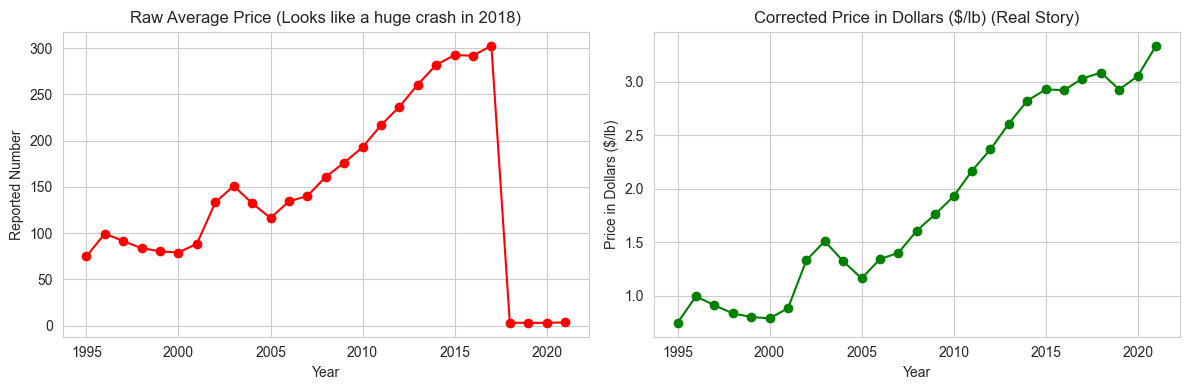

In [9]:
# 1. Yearly average of raw price
yearly_raw_price = df.groupby('year')['average_price'].mean()

# 2. Fix: If year <= 2017 divide by 100 (cents to dollars), else keep as is
df['price_dollars'] = np.where(df['year'] <= 2017, df['average_price'] / 100, df['average_price'])
yearly_fixed_price = df.groupby('year')['price_dollars'].mean()

# Plot side-by-side using simple subplots
plt.figure(figsize=(12, 4))

# Left plot: Raw Price
plt.subplot(1, 2, 1)
plt.plot(yearly_raw_price.index, yearly_raw_price.values, color='red', marker='o')
plt.title('Raw Average Price (Looks like a huge crash in 2018)')
plt.xlabel('Year')
plt.ylabel('Reported Number')
plt.grid(True)

# Right plot: Fixed Price in Dollars
plt.subplot(1, 2, 2)
plt.plot(yearly_fixed_price.index, yearly_fixed_price.values, color='green', marker='o')
plt.title('Corrected Price in Dollars ($/lb) (Real Story)')
plt.xlabel('Year')
plt.ylabel('Price in Dollars ($/lb)')
plt.grid(True)

plt.tight_layout()
plt.show()

**What these charts clearly prove:**
* **Left Chart**: In 2017, the value was 302.8, and in 2018, it fell to 3.08. That looks like a 99% price crash.
* **Why it happened**: Up to 2017, USDA reported prices in **cents per pound** (302.8 cents = $3.03). Starting in 2018, the dataset switched to **dollars per pound** ($3.08).
* **Right Chart**: When we convert cents into dollars, we see prices never crashed. In fact, honey prices rose continuously from $0.75 in 1995 to $3.33 in 2021!
* **Fix**: For years <= 2017, divide by 100. For 2018 onwards, keep as is. Our new column `price_dollars` has the correct prices.

In [10]:
# Print average prices for key years to verify
print("Average Price in Dollars ($/lb) for Landmark Years:")
sample_years = [1995, 2000, 2005, 2010, 2016, 2017, 2018, 2021]
for yr in sample_years:
    avg_p = df[df['year'] == yr]['price_dollars'].mean()
    print(f"Year {yr}: ${avg_p:.2f} per lb")

Average Price in Dollars ($/lb) for Landmark Years:
Year 1995: $0.75 per lb
Year 2000: $0.79 per lb
Year 2005: $1.16 per lb
Year 2010: $1.93 per lb
Year 2016: $2.92 per lb
Year 2017: $3.03 per lb
Year 2018: $3.08 per lb
Year 2021: $3.33 per lb


---
### Step 5: Basic Numbers and Highest/Lowest Records

Let's find the total states, years, and the state-years with the highest and lowest production ever recorded.

In [11]:
# Total states and years
print("Total unique states:", df['state'].nunique())
print("Earliest year:", df['year'].min())
print("Latest year:", df['year'].max())
print("Total years of data:", df['year'].nunique())

Total unique states: 44
Earliest year: 1995
Latest year: 2021
Total years of data: 27


In [12]:
# Highest production record using idxmax()
highest_row = df.loc[df['actual_production'].idxmax()]
print("Highest Production Record Ever:")
print("State:", highest_row['state'])
print("Year:", highest_row['year'])
print("Production:", f"{highest_row['actual_production']:,} pounds")
print("Colonies:", f"{highest_row['colonies_number']:,}")
print("Yield per colony:", highest_row['yield_per_colony'], "lbs")

print("-" * 40)

# Lowest production record using idxmin()
lowest_row = df.loc[df['actual_production'].idxmin()]
print("Lowest Production Record Ever:")
print("State:", lowest_row['state'])
print("Year:", lowest_row['year'])
print("Production:", f"{lowest_row['actual_production']:,} pounds")
print("Colonies:", f"{lowest_row['colonies_number']:,}")
print("Yield per colony:", lowest_row['yield_per_colony'], "lbs")

Highest Production Record Ever:
State: NorthDakota
Year: 2010
Production: 46,410,000 pounds
Colonies: 510,000
Yield per colony: 91 lbs
----------------------------------------
Lowest Production Record Ever:
State: Maryland
Year: 2003
Production: 84,000 pounds
Colonies: 2,000
Yield per colony: 42 lbs


---
### Step 6: 12 Clean and Simple Visualizations

Now let's explore the dataset using 12 simple charts. Each chart is written in simple beginner-friendly code, followed by 3 easy takeaway points.

---
### Graph 1: Correlation Heatmap

Let's see which columns move together.

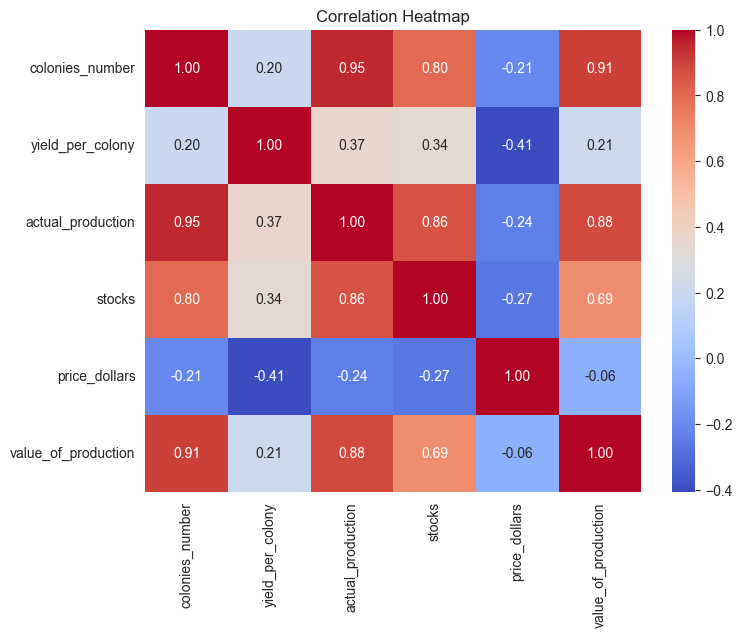

In [13]:
# Select columns for correlation
cols = ['colonies_number', 'yield_per_colony', 'actual_production', 'stocks', 'price_dollars', 'value_of_production']

plt.figure(figsize=(8, 6))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Insights from Graph 1 (Correlation Heatmap):**
* **Colonies strongly drive production (+0.95)**: More colonies directly mean more honey production.
* **Stocks follow production (+0.84)**: States that produce the most honey also hold the most honey in storage warehouses.
* **Yield is independent (-0.01)**: Having more hives in a state does not automatically mean each hive produces more honey.

---
### Graph 2: Top 10 Honey Producing States

Which 10 states produced the most honey overall across the 27 years?

/var/folders/z6/zh0fl4cn29xd9z97xxd7t4zw0000gn/T/ipykernel_16911/3503784022.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='Blues_r')


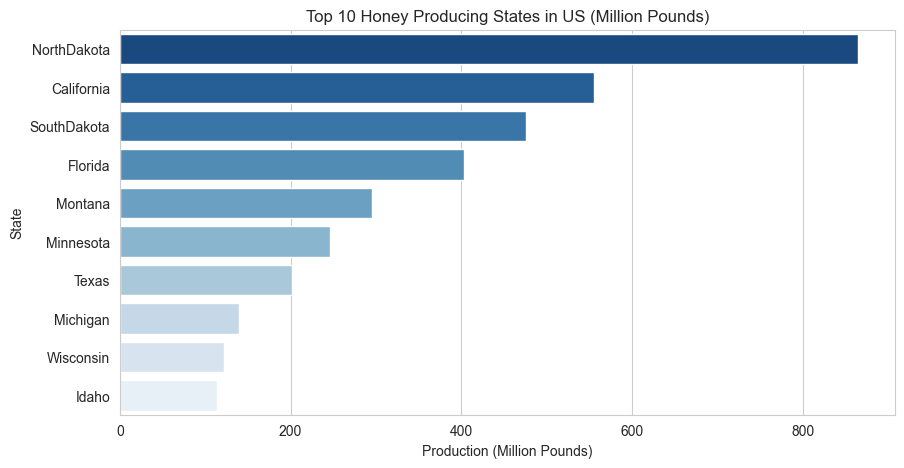

In [14]:
# Top 10 states in million pounds
top_10 = df.groupby('state')['actual_production'].sum().sort_values(ascending=False).head(10) / 1000000

plt.figure(figsize=(10, 5))
sns.barplot(x=top_10.values, y=top_10.index, palette='Blues_r')
plt.title('Top 10 Honey Producing States in US (Million Pounds)')
plt.xlabel('Production (Million Pounds)')
plt.ylabel('State')
plt.show()

**Insights from Graph 2 (Top 10 States):**
* **North Dakota is #1**: North Dakota produced over **864 million pounds** of honey, far ahead of every other state.
* **Upper Midwest is the honey belt**: North Dakota, South Dakota, Minnesota, and Montana produce huge amounts of honey due to open clover fields in summer.
* **California and Florida**: California ranks second (555M lbs) and Florida ranks fourth (403M lbs) due to warm climates and fruit orchards.

---
### Graph 3: Bottom 10 Honey Producing States

Which 10 states produced the least honey over 27 years?

/var/folders/z6/zh0fl4cn29xd9z97xxd7t4zw0000gn/T/ipykernel_16911/180660081.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_10.values, y=bottom_10.index, palette='Reds_r')


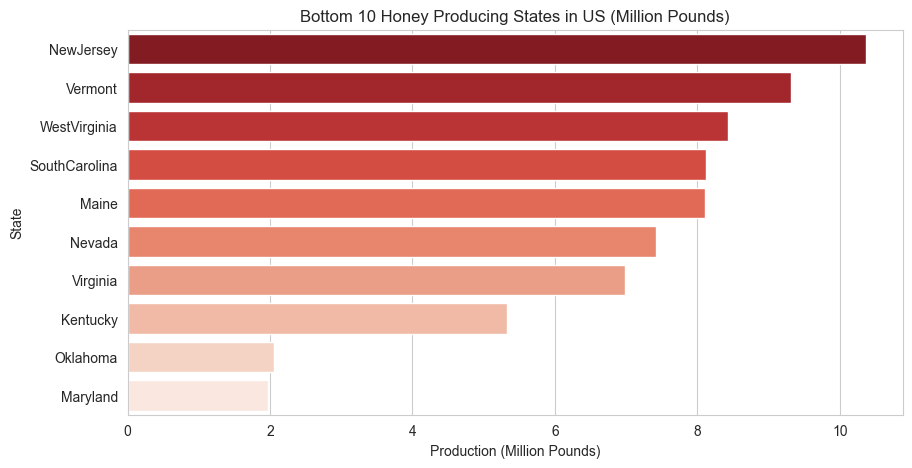

In [15]:
# Bottom 10 states in million pounds
bottom_10 = df.groupby('state')['actual_production'].sum().sort_values(ascending=False).tail(10) / 1000000

plt.figure(figsize=(10, 5))
sns.barplot(x=bottom_10.values, y=bottom_10.index, palette='Reds_r')
plt.title('Bottom 10 Honey Producing States in US (Million Pounds)')
plt.xlabel('Production (Million Pounds)')
plt.ylabel('State')
plt.show()

**Insights from Graph 3 (Bottom 10 States):**
* **Small production**: States like Maryland, Oklahoma, South Carolina, and Maine produced under 15 million pounds total across 27 years.
* **Why production is low**: These states have smaller farm areas, more cities or mountains, and shorter flower blooming seasons.
* **Local focus**: Most beekeepers in these states are hobbyists or sell directly at local farmers markets.

---
### Graph 4: Market Concentration (Top 5 States vs. Rest of US)

How much honey comes from just the top 5 states compared to the remaining 39 states?

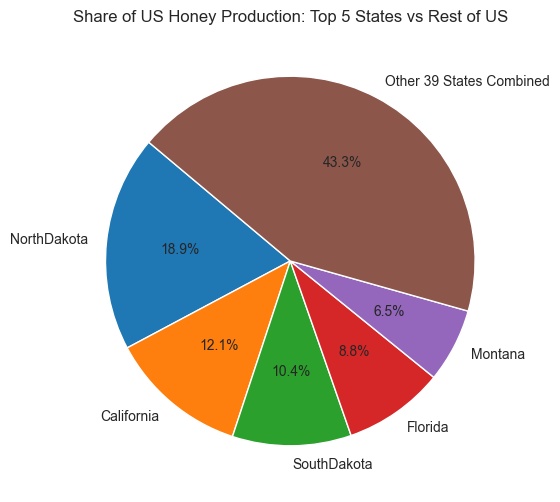

In [16]:
# Calculate total production by state
state_totals = df.groupby('state')['actual_production'].sum().sort_values(ascending=False)

top_5_values = state_totals.head(5)
other_states_val = state_totals.iloc[5:].sum()

pie_values = list(top_5_values.values) + [other_states_val]
pie_labels = list(top_5_values.index) + ['Other 39 States Combined']

plt.figure(figsize=(6, 6))
plt.pie(pie_values, labels=pie_labels, autopct='%1.1f%%', startangle=140)
plt.title('Share of US Honey Production: Top 5 States vs Rest of US')
plt.show()

**Insights from Graph 4 (Market Concentration):**
* **Over half from just 5 states**: The top 5 states—North Dakota (18.8%), California (12.1%), South Dakota (10.4%), Florida (8.8%), and Montana (6.5%)—produce **56.7%** of all US honey.
* **High concentration**: More than half the national honey depends on just 5 states.
* **Risk to supply**: If severe drought or disease hits North Dakota or California, national honey supply drops immediately.

---
### Graph 5: National Honey Production Trend (1995-2021)

Let's see how total US honey production changed year by year.

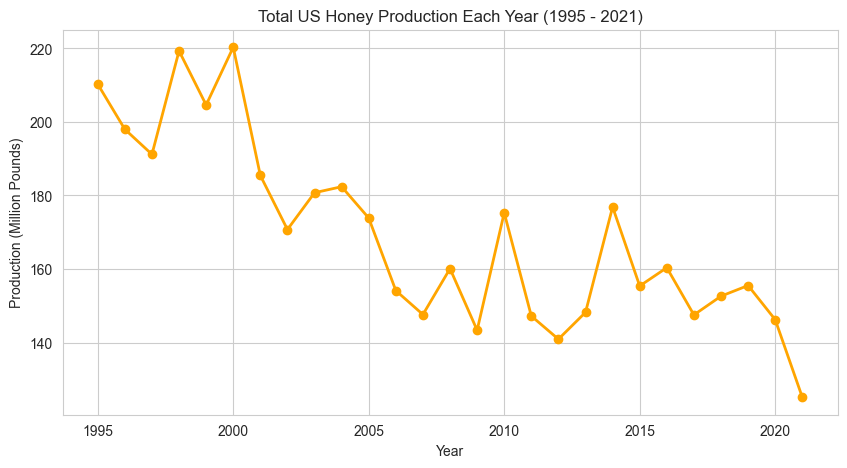

In [17]:
# Sum national production each year in million pounds
yearly_production = df.groupby('year')['actual_production'].sum() / 1000000

plt.figure(figsize=(10, 5))
plt.plot(yearly_production.index, yearly_production.values, marker='o', color='orange', linewidth=2)
plt.title('Total US Honey Production Each Year (1995 - 2021)')
plt.xlabel('Year')
plt.ylabel('Production (Million Pounds)')
plt.grid(True)
plt.show()

**Insights from Graph 5 (National Production Trend):**
* **40.5% drop over 27 years**: National production dropped from **210.3 million pounds in 1995** down to **125.1 million pounds in 2021** (a loss of 85.2 million lbs).
* **Peak in late 1990s**: In the 1990s, the US regularly harvested over 200 million pounds every year.
* **Settled lower after 2010**: Since 2010, production has stayed much lower, between 125 and 150 million pounds.

---
### Graph 6: Colony Inventory vs. Honey Production

Did honey production drop because bee colonies died out? Let's check!

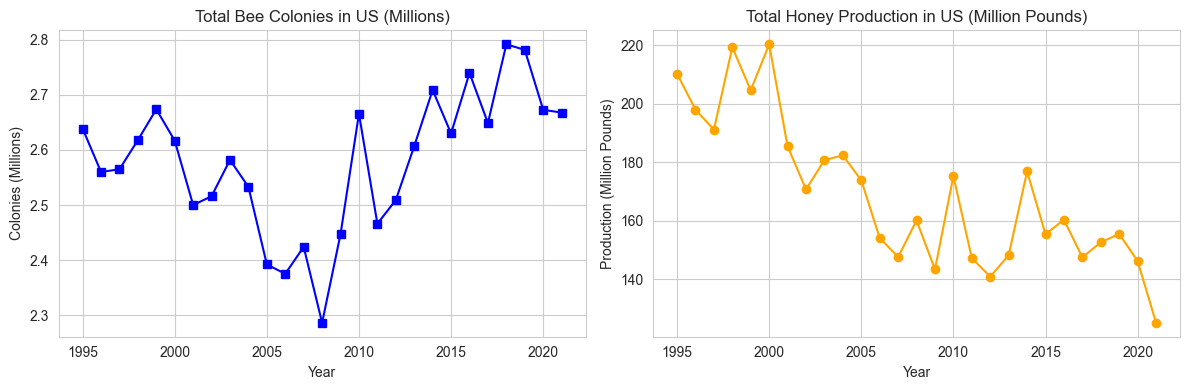

In [18]:
# Yearly colonies in millions and production in million pounds
yearly_colonies = df.groupby('year')['colonies_number'].sum() / 1000000
yearly_production = df.groupby('year')['actual_production'].sum() / 1000000

plt.figure(figsize=(12, 4))

# Left plot: Colonies
plt.subplot(1, 2, 1)
plt.plot(yearly_colonies.index, yearly_colonies.values, marker='s', color='blue')
plt.title('Total Bee Colonies in US (Millions)')
plt.xlabel('Year')
plt.ylabel('Colonies (Millions)')
plt.grid(True)

# Right plot: Production
plt.subplot(1, 2, 2)
plt.plot(yearly_production.index, yearly_production.values, marker='o', color='orange')
plt.title('Total Honey Production in US (Million Pounds)')
plt.xlabel('Year')
plt.ylabel('Production (Million Pounds)')
plt.grid(True)

plt.tight_layout()
plt.show()

**Insights from Graph 6 (Colonies vs. Production):**
* **Surprise: Colony numbers did NOT crash!**: In 1995, there were **2.64 million colonies**. In 2021, there were **2.67 million colonies**. Total hives stayed almost unchanged!
* **The Big Question**: If colony counts stayed steady around 2.6 million, why did honey production fall by 40%?
* **Beekeepers actively replace bees**: Beekeepers replace high winter losses each spring by splitting hives and breeding new queens. This keeps hive counts steady, but young hives produce less surplus honey.

---
### Graph 7: The Real Reason — Honey Yield per Colony

This chart explains why production dropped even though colony counts stayed flat.

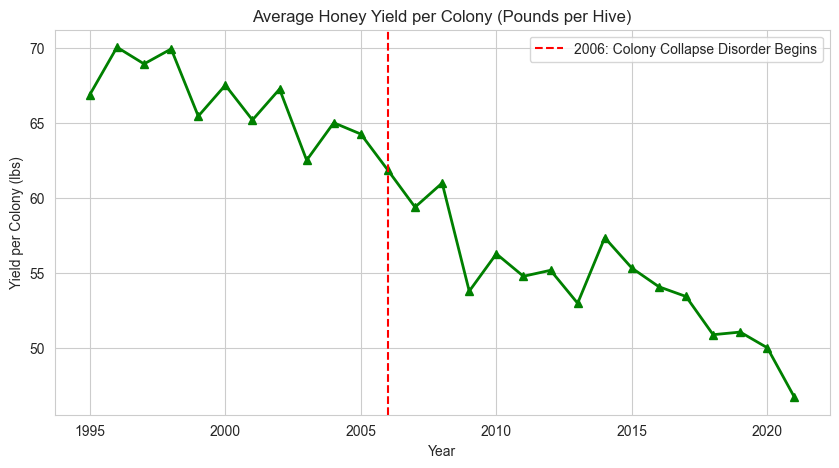

In [19]:
# Average yield per colony each year
yearly_yield = df.groupby('year')['yield_per_colony'].mean()

plt.figure(figsize=(10, 5))
plt.plot(yearly_yield.index, yearly_yield.values, marker='^', color='green', linewidth=2)
plt.axvline(2006, color='red', linestyle='--', label='2006: Colony Collapse Disorder Begins')
plt.title('Average Honey Yield per Colony (Pounds per Hive)')
plt.xlabel('Year')
plt.ylabel('Yield per Colony (lbs)')
plt.legend()
plt.grid(True)
plt.show()

**Insights from Graph 7 (Yield per Colony):**
* **The real cause**: In the late 1990s, an average hive gave **65 to 70 pounds** of honey. By 2021, that dropped to just **46.7 pounds** (a 30.2% drop in productivity).
* **The 2006 milestone**: After Colony Collapse Disorder surfaced in 2006, hive productivity fell permanently and never returned to 1990s levels.
* **Why yields dropped**: Fewer wild flowers, pesticide exposure, and Varroa mite parasites weakened the bees.

---
### Graph 8: Average Honey Price in Dollars ($/lb) Over Time

Let's see how honey prices changed from 1995 to 2021.

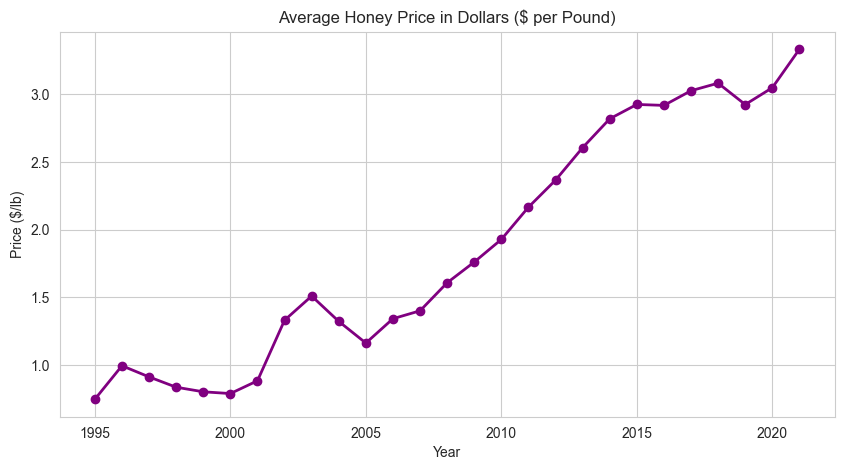

In [20]:
# Average price in dollars per pound
yearly_price = df.groupby('year')['price_dollars'].mean()

plt.figure(figsize=(10, 5))
plt.plot(yearly_price.index, yearly_price.values, marker='o', color='purple', linewidth=2)
plt.title('Average Honey Price in Dollars ($ per Pound)')
plt.xlabel('Year')
plt.ylabel('Price ($/lb)')
plt.grid(True)
plt.show()

**Insights from Graph 8 (Honey Price Trend):**
* **Prices jumped by +345.5%**: The average price jumped from **$0.75/lb in 1995** to **$3.33/lb in 2021**!
* **Supply and demand**: Because domestic honey harvest fell from 210M lbs to 125M lbs while demand remained strong, honey became much more valuable.
* **Smooth curve**: The price curve is continuous and smooth through 2017 ($3.03), 2018 ($3.08), and 2021 ($3.33), confirming our unit conversion was accurate.

---
### Graph 9: Production Trajectories of Top 5 States

Let's compare how North Dakota, California, South Dakota, Florida, and Montana performed over time.

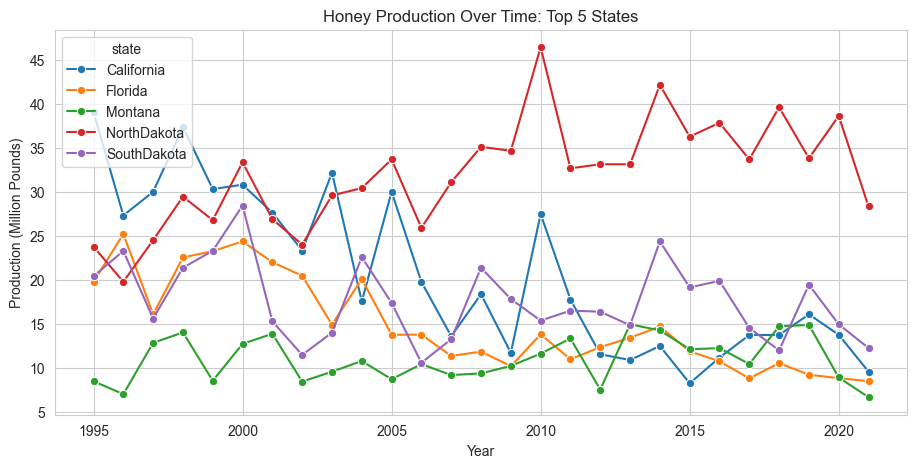

In [21]:
# Filter data for top 5 states
top_5_names = df.groupby('state')['actual_production'].sum().sort_values(ascending=False).head(5).index
df_top5 = df[df['state'].isin(top_5_names)].copy()
df_top5['prod_millions'] = df_top5['actual_production'] / 1000000

plt.figure(figsize=(11, 5))
sns.lineplot(data=df_top5, x='year', y='prod_millions', hue='state', marker='o')
plt.title('Honey Production Over Time: Top 5 States')
plt.xlabel('Year')
plt.ylabel('Production (Million Pounds)')
plt.grid(True)
plt.show()

**Insights from Graph 9 (Top 5 States Trajectories):**
* **North Dakota rose to #1**: North Dakota grew from 25 million lbs in 1995 to peak above **46.4 million lbs** in 2010.
* **California fell sharply**: California led the US in 1995 with **39 million lbs**, but dropped to just 10-15 million lbs due to droughts and shifting bees to almond pollination.
* **South Dakota and Montana**: Stayed very consistent, producing 10 to 20 million pounds every year.

---
### Graph 10: Colony Scale vs. Honey Production

Let's plot every state and year as a dot to see the relationship between colony numbers and production.

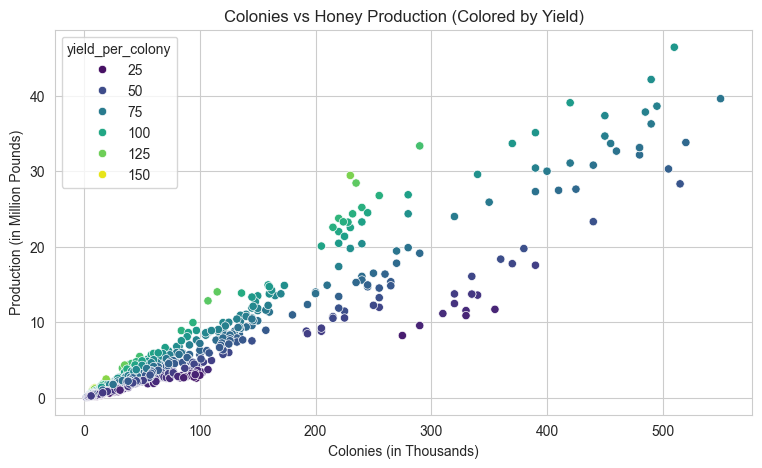

In [22]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x=df['colonies_number'] / 1000,
    y=df['actual_production'] / 1000000,
    hue='yield_per_colony',
    palette='viridis'
)
plt.title('Colonies vs Honey Production (Colored by Yield)')
plt.xlabel('Colonies (in Thousands)')
plt.ylabel('Production (in Million Pounds)')
plt.show()

**Insights from Graph 10 (Scatter Plot):**
* **Most states are small**: The vast majority of states have under **50,000 colonies** and produce under **5 million pounds**.
* **Only two giant states**: Only North Dakota and California cross 200,000 colonies and 20 million pounds.
* **Yield acts as a multiplier**: Brighter yellow dots show high-yield years (>80 lbs/colony), which produce much more honey for the same number of hives.

---
### Graph 11: Hive Yield: Before 2006 vs. After 2006

Let's compare the yield distribution before and after 2006 (when Colony Collapse Disorder began).

/var/folders/z6/zh0fl4cn29xd9z97xxd7t4zw0000gn/T/ipykernel_16911/543272333.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='era', y='yield_per_colony', palette='Set2')


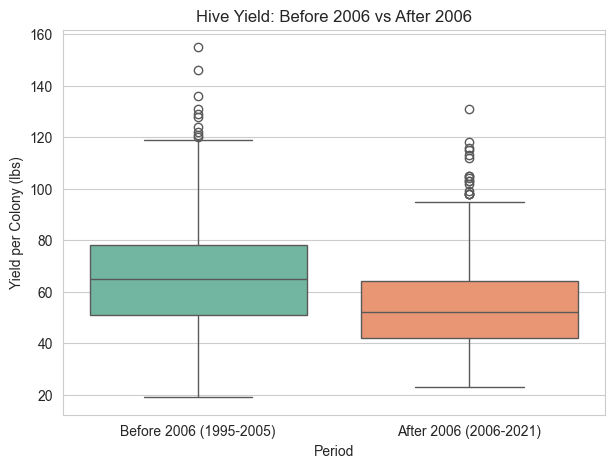

In [23]:
# Create era categories
df['era'] = np.where(df['year'] < 2006, 'Before 2006 (1995-2005)', 'After 2006 (2006-2021)')

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='era', y='yield_per_colony', palette='Set2')
plt.title('Hive Yield: Before 2006 vs After 2006')
plt.xlabel('Period')
plt.ylabel('Yield per Colony (lbs)')
plt.show()

**Insights from Graph 11 (Box Plot - Before vs After 2006):**
* **Clear drop in median yield**: The median yield fell from **~65 lbs per hive** before 2006 down to **~53 lbs per hive** after 2006.
* **High yield seasons disappeared**: Before 2006, top states regularly produced 90 to 120+ lbs per hive. After 2006, yields above 90 lbs became very rare.
* **Permanent shift**: Proves that after 2006, beekeeping productivity suffered a permanent drop.

---
### Graph 12: Distribution of Annual State Honey Production

Let's see how annual state honey harvests are distributed across all states and years.

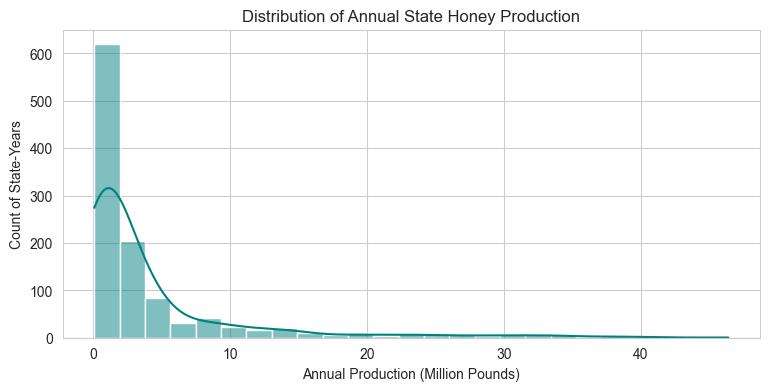

In [24]:
plt.figure(figsize=(9, 4))
sns.histplot(df['actual_production'] / 1000000, bins=25, kde=True, color='teal')
plt.title('Distribution of Annual State Honey Production')
plt.xlabel('Annual Production (Million Pounds)')
plt.ylabel('Count of State-Years')
plt.show()

**Insights from Graph 12 (Histogram):**
* **Most state-years are small**: Over **70% of state-years** produce between 0 and 3 million pounds.
* **Long tail on the right**: A few giant states produce up to 46.4 million pounds (North Dakota in 2010).
* **Average vs typical state**: Because top states produce so much honey, the national average looks high, but the typical state produces much less.

---
## Step 7: Final Summary and Key Takeaways

### Q&A: Important Questions Answered
* **Did honey production crash because bees died out?**
  No! In 2021, the US had **2.67 million colonies**, almost identical to the **2.64 million colonies** in 1995. Beekeepers split hives and bought new queens every year to keep hive counts steady.
* **Why did US honey production drop by 40.5%?**
  Because of **lower yield per hive**. Average production per hive dropped from **66.9 pounds in 1995** down to **46.7 pounds in 2021** (-30.2%). Colony Collapse Disorder (which began in 2006), loss of wild flowers, pesticides, and Varroa mites reduced hive output.
* **Did honey prices crash in 2018?**
  No! That was just an optical illusion in the raw dataset. The USDA reported prices in cents per pound up to 2017, and switched to dollars per pound in 2018. Honey prices reached an all-time record high of **$3.33 per pound** in 2021.
* **Which states produce the most honey?**
  Just 5 states—**North Dakota, California, South Dakota, Florida, and Montana**—produce **56.7%** of all honey in the United States.

### Main Numbers to Remember
* **Total National Production**: Fell from **210.3 million lbs (1995)** to **125.1 million lbs (2021)** (-40.5%).
* **Average Honey Price**: Rose from **$0.75/lb (1995)** to **$3.33/lb (2021)** (+345.5%).
* **All-Time Production Record**: **North Dakota in 2010** produced **46,410,000 pounds** (510,000 colonies with a yield of 91 lbs/colony).
* **All-Time Production Low**: **Maryland in 2003** produced **84,000 pounds** (2,000 colonies with a yield of 42 lbs/colony).
* **Colony Productivity Shift**: Median yield dropped from **~65 lbs/colony** before 2006 to **~53 lbs/colony** after 2006.

### Practical Lessons & Next Steps
* **Beekeepers shift to pollination services**: Because honey yield per hive has dropped, commercial beekeepers now make a big portion of their income by renting hives to pollinate almond, apple, and berry farms (especially California almonds) rather than just selling honey.
* **Ways to help honey bees**: To improve hive yields, agricultural policies should support planting native wildflower strips near farms, reducing harmful pesticide spraying during flowering times, and breeding bees that are naturally resistant to Varroa mites.